In [1]:
# ==========================================================
# 1. Imports
# ==========================================================

import os
import re
import cv2
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses      = []
val_losses        = []
train_accuracies  = []
val_accuracies    = []
lr_cls_history    = []
lr_enc_history    = []


In [2]:
# ==========================================================
# 2. Transforms
# ==========================================================

ssl_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.GaussianBlur(3),
    T.ToTensor()          # (1, H, W)
])

cls_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()          # (1, H, W)
])

# ✅ OPT: Lightweight augment for sub-regions (quads/patches).
# Skips Resize+GaussianBlur — sub-regions are already small tensors;
# re-resizing them adds latency with negligible SSL benefit.
sub_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()
])


In [3]:
# ==========================================================
# 3. Quadrants + Multi-scale patches
# ==========================================================

def split_quadrants(img):
    c, h, w = img.shape
    h2, w2  = h // 2, w // 2

    return [
        img[:, 0:h2,  0:w2],
        img[:, 0:h2,  w2:w],
        img[:, h2:h,  0:w2],
        img[:, h2:h,  w2:w]
    ]


def extract_patches(img):
    c, h, w = img.shape

    patches = []
    sizes   = [56, 112]

    for s in sizes:
        for _ in range(2):
            y = random.randint(0, h - s)
            x = random.randint(0, w - s)
            patches.append(img[:, y:y + s, x:x + s])

    return patches


In [4]:
# ==========================================================
# 4. Regex Label Extraction
# ==========================================================

def extract_label(name):

    if re.search("malignant", name, re.I):
        return 1

    if re.search("benign", name, re.I):
        return 0

    return -1


In [5]:
# ==========================================================
# 5. SSL Dataset
# ✅ OPT: Sub-region augmentation is now pure-tensor (no PIL round-trip).
#
# Original code converted every quad/patch back to PIL inside __getitem__
# (T.ToPILImage → .convert("L") → ssl_transform) — that's 8 PIL round-trips
# per sample, all on CPU, all blocking the DataLoader worker.
#
# New approach:
#   1. Apply random flips + rotation directly on the float tensor slice.
#      TF (torchvision.transforms.functional) works on CHW tensors natively.
#   2. Resize the small patches to 56×56 with F.interpolate so they all
#      share the same spatial size — required for stacking into a batch.
#   3. Stacking is done here once in __getitem__ rather than in the
#      training loop, reducing per-step overhead further.
# ==========================================================

import torch.nn.functional as F

def _augment_tensor(t):
    """Lightweight augment for a CHW float tensor (no PIL, no Resize)."""
    if random.random() > 0.5:
        t = TF.hflip(t)
    angle = random.uniform(-10, 10)
    t = TF.rotate(t, angle)
    return t


def _resize_tensor(t, size=56):
    """Resize a CHW tensor to (size, size) for uniform stacking."""
    return F.interpolate(
        t.unsqueeze(0), size=(size, size), mode='bilinear', align_corners=False
    ).squeeze(0)


class SSLDataset(Dataset):

    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = Image.open(self.files[idx]).convert("L")  # direct grayscale

        view1 = ssl_transform(img)
        view2 = ssl_transform(img)

        quads   = split_quadrants(view1)
        patches = extract_patches(view1)

        # ✅ OPT: Pure-tensor augment — no PIL round-trip
        quad_aug1 = torch.stack([_augment_tensor(q) for q in quads])        # (4,1,H/2,W/2)
        quad_aug2 = torch.stack([_augment_tensor(q) for q in quads])

        # ✅ OPT: Resize patches to common size then augment — no PIL
        patches_r  = [_resize_tensor(p, 56) for p in patches]
        patch_aug1 = torch.stack([_augment_tensor(p) for p in patches_r])   # (4,1,56,56)
        patch_aug2 = torch.stack([_augment_tensor(p) for p in patches_r])

        return view1, view2, quad_aug1, quad_aug2, patch_aug1, patch_aug2


In [6]:
# ==========================================================
# 6. Supervised Dataset
# ==========================================================

class ThermoDataset(Dataset):

    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        img = Image.open(path).convert("L")  # direct grayscale

        img = cls_transform(img)

        label = extract_label(path)

        return img, label


In [7]:
# ==========================================================
# 7. Encoder
# ==========================================================

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        base = resnet50(weights=None)

        base.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=7, stride=2, padding=3, bias=False
        )

        self.backbone  = nn.Sequential(*list(base.children())[:-2])
        self.pool      = nn.AdaptiveAvgPool2d((1, 1))
        self.projector = nn.Linear(2048, 512)

    def forward(self, x):

        fmap = self.backbone(x)

        g = self.pool(fmap)
        g = g.view(g.size(0), -1)
        g = self.projector(g)

        return fmap, g


In [8]:
# ==========================================================
# 8. Gated Fusion
# ==========================================================

class GatedFusion(nn.Module):

    def __init__(self, spatial_dim=4096, ssl_dim=512, out_dim=512):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(spatial_dim + ssl_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
            nn.Sigmoid()
        )

        self.proj_spatial = nn.Linear(spatial_dim, out_dim)
        self.proj_ssl     = nn.Linear(ssl_dim, out_dim)

    def forward(self, spatial_feat, ssl_feat):

        combined = torch.cat([spatial_feat, ssl_feat], dim=1)
        gate = self.gate(combined)

        fused = gate * self.proj_spatial(spatial_feat) \
              + (1 - gate) * self.proj_ssl(ssl_feat)

        return fused


In [9]:
# ==========================================================
# 9. Losses
# ==========================================================

def vicreg(x, y):

    sim = nn.functional.mse_loss(x, y)

    std_x = torch.sqrt(x.var(0) + 1e-4)
    std_y = torch.sqrt(y.var(0) + 1e-4)

    var  = torch.mean(nn.functional.relu(1 - std_x))
    var += torch.mean(nn.functional.relu(1 - std_y))

    return sim + var


def symmetry_loss(fmap):

    flipped = torch.flip(fmap, [3])
    return torch.mean((fmap - flipped) ** 2)


In [10]:
# ==========================================================
# 13. SSL Pretraining
# ✅ Gradient accumulation (effective batch 32 from physical 8)
# ✅ Mixed precision (autocast + GradScaler)
# ✅ Stacked forward passes for quadrants and patches
# ✅ OPT: Removed torch.cuda.empty_cache() from inner loop —
#         it forces a full CUDA sync on every accumulation step,
#         adding ~50-200 ms overhead per call; only call at epoch end.
# ✅ OPT: Moved all sub-region .to(device) calls outside autocast
#         to overlap H2D transfer with CPU work.
# ✅ OPT: non_blocking=True on all .to(device) calls so the CPU
#         doesn't stall waiting for the transfer to complete.
# ==========================================================

def pretrain(model, loader, epochs=60):

    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Single cosine scheduler — no conflict
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )

    # Mixed precision scaler — halves GPU memory usage almost for free
    scaler = torch.cuda.amp.GradScaler()

    # Effective batch size = physical batch (8) × accumulation steps (4) = 32
    ACCUMULATION_STEPS = 4

    for epoch in range(epochs):

        total_loss = 0

        # zero_grad outside the batch loop — gradients accumulate across steps
        optimizer.zero_grad()

        for step, (v1, v2, quad_aug1, quad_aug2, patch_aug1, patch_aug2) in enumerate(loader):

            # ✅ OPT: non_blocking=True overlaps H2D transfer with CPU preprocessing
            v1 = v1.to(device, non_blocking=True)
            v2 = v2.to(device, non_blocking=True)

            B,  N,  C,  H,  W  = quad_aug1.shape
            Bp, Np, Cp, Hp, Wp = patch_aug1.shape

            # ✅ OPT: Move and reshape outside autocast so transfers overlap
            q1_all = quad_aug1.view(B  * N,  C,  H,  W ).to(device, non_blocking=True)
            q2_all = quad_aug2.view(B  * N,  C,  H,  W ).to(device, non_blocking=True)
            p1_all = patch_aug1.view(Bp * Np, Cp, Hp, Wp).to(device, non_blocking=True)
            p2_all = patch_aug2.view(Bp * Np, Cp, Hp, Wp).to(device, non_blocking=True)

            # All forward passes wrapped in autocast for mixed precision
            with torch.cuda.amp.autocast():

                fmap1, g1 = model(v1)
                fmap2, g2 = model(v2)

                loss_global = vicreg(g1, g2)

                _, z1_quads = model(q1_all)
                _, z2_quads = model(q2_all)

                z1_quads = z1_quads.view(B, N, -1).unbind(dim=1)
                z2_quads = z2_quads.view(B, N, -1).unbind(dim=1)

                quad_losses = [vicreg(z1, z2) for z1, z2 in zip(z1_quads, z2_quads)]

                _, z1_patches = model(p1_all)
                _, z2_patches = model(p2_all)

                z1_patches = z1_patches.view(Bp, Np, -1).unbind(dim=1)
                z2_patches = z2_patches.view(Bp, Np, -1).unbind(dim=1)

                patch_losses = [vicreg(z1, z2) for z1, z2 in zip(z1_patches, z2_patches)]

                local_losses = quad_losses + patch_losses

                loss_local = sum(local_losses) / len(local_losses)

                loss_sym = symmetry_loss(fmap1)

                # Scale loss by accumulation steps so effective gradient
                # magnitude matches a true batch of 32
                loss = (loss_global + loss_local + loss_sym) / ACCUMULATION_STEPS

            # Scaler backward — works correctly with mixed precision
            scaler.scale(loss).backward()

            # Log unscaled loss for interpretable printing
            total_loss += loss.item() * ACCUMULATION_STEPS

            # Step optimizer only every ACCUMULATION_STEPS batches
            if (step + 1) % ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                # ✅ OPT: Removed empty_cache() here — it caused a CUDA sync
                #         every 4 steps (hundreds of times per epoch).

        # Handle leftover steps if dataset size isn't divisible by ACCUMULATION_STEPS
        if (step + 1) % ACCUMULATION_STEPS != 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        scheduler.step()

        print("SSL Epoch:", epoch, "Loss:", total_loss / len(loader))

        # ✅ OPT: empty_cache once per epoch only — safe and much less overhead
        torch.cuda.empty_cache()

    torch.save(model.state_dict(),
               "/kaggle/working/pretrained_encoder.pth")

    print("Pretrained encoder saved")


In [11]:
# ==========================================================
# 14. Classifier
# ClassifierHead input = 512 (fused output from GatedFusion)
# ThermoClassifier uses GatedFusion to combine spatial + SSL features
# ==========================================================

class ClassifierHead(nn.Module):

    def __init__(self, in_dim=512):
        super().__init__()

        self.net = nn.Sequential(

            nn.LayerNorm(in_dim),

            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


class ThermoClassifier(nn.Module):

    def __init__(self, encoder):
        super().__init__()

        self.encoder = encoder

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.maxpool = nn.AdaptiveMaxPool2d((1, 1))

        # GatedFusion combines spatial features with SSL projection g
        self.fusion = GatedFusion(spatial_dim=4096, ssl_dim=512, out_dim=512)

        self.classifier = ClassifierHead(in_dim=512)

    def forward(self, x):

        fmap, g = self.encoder(x)                              # fmap: (B,2048,7,7), g: (B,512)

        avg = self.avgpool(fmap).view(x.size(0), -1)           # (B, 2048)
        mx  = self.maxpool(fmap).view(x.size(0), -1)           # (B, 2048)

        spatial = torch.cat([avg, mx], dim=1)                  # (B, 4096)

        fused = self.fusion(spatial, g)                        # (B, 512)

        return self.classifier(fused)


In [12]:
# ==========================================================
# 15. Training + Validation Tracking
# ✅ Mixed precision (autocast + GradScaler)
# Single scheduler (cosine with warmup via LambdaLR)
# Gradual encoder unfreezing (layer-by-layer)
# ✅ OPT: non_blocking=True on all .to(device) calls
# ✅ OPT: Removed torch.cuda.empty_cache() from inner loop
# ✅ OPT: optimizer.zero_grad(set_to_none=True) — frees gradient
#         memory immediately instead of zeroing it, saving ~1 write
#         pass per parameter per step
# ==========================================================

def train_classifier(model, train_loader, val_loader, epochs=60):

    # Start with encoder fully frozen
    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = optim.AdamW([
        {"params": model.classifier.parameters(), "lr": 1e-3},
        {"params": model.fusion.parameters(),      "lr": 1e-3},
        {"params": model.encoder.parameters(),     "lr": 1e-5}
    ])

    # Mixed precision scaler for fine-tuning
    scaler = torch.amp.GradScaler('cuda')

    warmup_epochs = 5

    # ONE scheduler only — cosine with linear warmup; no ReduceLROnPlateau conflict
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=[
            # classifier: warmup → cosine
            lambda epoch: (
                (epoch + 1) / warmup_epochs
                if epoch < warmup_epochs
                else 0.5 * (1 + np.cos(
                    np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
                ))
            ),
            # fusion head: same schedule as classifier
            lambda epoch: (
                (epoch + 1) / warmup_epochs
                if epoch < warmup_epochs
                else 0.5 * (1 + np.cos(
                    np.pi * (epoch - warmup_epochs) / (epochs - warmup_epochs)
                ))
            ),
            # encoder: slow cosine, no warmup
            lambda epoch: 0.5 * (1 + np.cos(np.pi * epoch / (epochs * 2)))
        ]
    )

    ce = nn.CrossEntropyLoss()

    best_val_acc = 0

    for epoch in range(epochs):

        # Gradual layer-by-layer unfreezing
        if epoch == 5:
            for p in model.encoder.backbone[-1].parameters():
                p.requires_grad = True
            print("Epoch 5: Unfroze encoder last block")

        if epoch == 15:
            for p in model.encoder.backbone[-2].parameters():
                p.requires_grad = True
            print("Epoch 15: Unfroze encoder second-to-last block")

        if epoch == 25:
            for p in model.encoder.parameters():
                p.requires_grad = True
            print("Epoch 25: Unfroze entire encoder")

        model.train()

        preds      = []
        gts        = []
        total_loss = 0

        for img, label in train_loader:

            # ✅ OPT: non_blocking=True overlaps H2D transfer
            img   = img.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)

            # Mixed precision forward pass
            with torch.amp.autocast('cuda'):
                out  = model(img)
                loss = ce(out, label)

            # ✅ OPT: set_to_none=True frees gradient tensors instead of
            #         zeroing them — avoids one full write pass per param
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            preds += out.argmax(1).cpu().tolist()
            gts   += label.cpu().tolist()

        train_acc = accuracy_score(gts, preds)

        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_acc)

        model.eval()

        v_preds  = []
        v_gts    = []
        val_loss = 0

        with torch.no_grad():

            for img, label in val_loader:

                # ✅ OPT: non_blocking=True
                img   = img.to(device, non_blocking=True)
                label = label.to(device, non_blocking=True)

                # Mixed precision for validation too
                with torch.amp.autocast('cuda'):
                    out  = model(img)
                    loss = ce(out, label)

                val_loss += loss.item()

                v_preds += out.argmax(1).cpu().tolist()
                v_gts   += label.cpu().tolist()

        val_acc = accuracy_score(v_gts, v_preds)

        # Single scheduler step
        scheduler.step()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        lr_cls = optimizer.param_groups[0]['lr']
        lr_enc = optimizer.param_groups[2]['lr']

        lr_cls_history.append(lr_cls)
        lr_enc_history.append(lr_enc)

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(model.state_dict(),
                       "/kaggle/working/final_finetuned_model.pth")

            print("Best model saved  (val_acc={:.4f})".format(val_acc))

        print("Epoch", epoch,
              "| Train Acc:", round(train_acc, 4),
              "| Val Acc:",   round(val_acc, 4),
              "| LR_cls:",    round(lr_cls, 6),
              "| LR_enc:",    round(lr_enc, 8))

        # ✅ OPT: empty_cache once per epoch only
        torch.cuda.empty_cache()


In [13]:
# ==========================================================
# 16. Evaluation + Metrics
# ✅ Mixed precision (autocast inside torch.no_grad)
# ✅ OPT: non_blocking=True on .to(device)
# ==========================================================

def evaluate(model, loader):

    model.eval()

    preds = []
    gts   = []

    with torch.no_grad():

        for img, label in loader:

            img = img.to(device, non_blocking=True)

            # Mixed precision — consistent with training, saves memory during TTA
            with torch.cuda.amp.autocast():
                out1 = model(img)
                out2 = model(torch.flip(img, [3]))   # horizontal flip
                out3 = model(torch.flip(img, [2]))   # vertical flip

            # Average predictions (TTA)
            out = (out1 + out2 + out3) / 3

            preds += out.argmax(1).cpu().tolist()
            gts   += label.tolist()

    acc = accuracy_score(gts, preds)
    f1  = f1_score(gts, preds)

    print("Test Accuracy:", acc)
    print("F1 Score:",      f1)

    cm = confusion_matrix(gts, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report\n")
    print(classification_report(gts, preds,
          target_names=["Benign", "Malignant"]))


In [14]:
# ==========================================================
# 17. Training Curves
# ==========================================================

def plot_training():

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses,   label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, label="Train Acc")
    plt.plot(epochs, val_accuracies,   label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 3, 3)
    plt.plot(epochs, lr_cls_history, label="Classifier LR")
    plt.plot(epochs, lr_enc_history, label="Encoder LR")
    plt.legend()
    plt.title("Learning Rates")

    plt.tight_layout()
    plt.show()


def plot_lr_vs_loss():

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(lr_cls_history, train_losses, marker='o')
    plt.xlabel("Classifier LR")
    plt.ylabel("Train Loss")
    plt.title("Loss vs LR (Classifier)")

    plt.subplot(1, 2, 2)
    plt.plot(lr_enc_history, train_losses, marker='o')
    plt.xlabel("Encoder LR")
    plt.ylabel("Train Loss")
    plt.title("Loss vs LR (Encoder)")

    plt.tight_layout()
    plt.show()


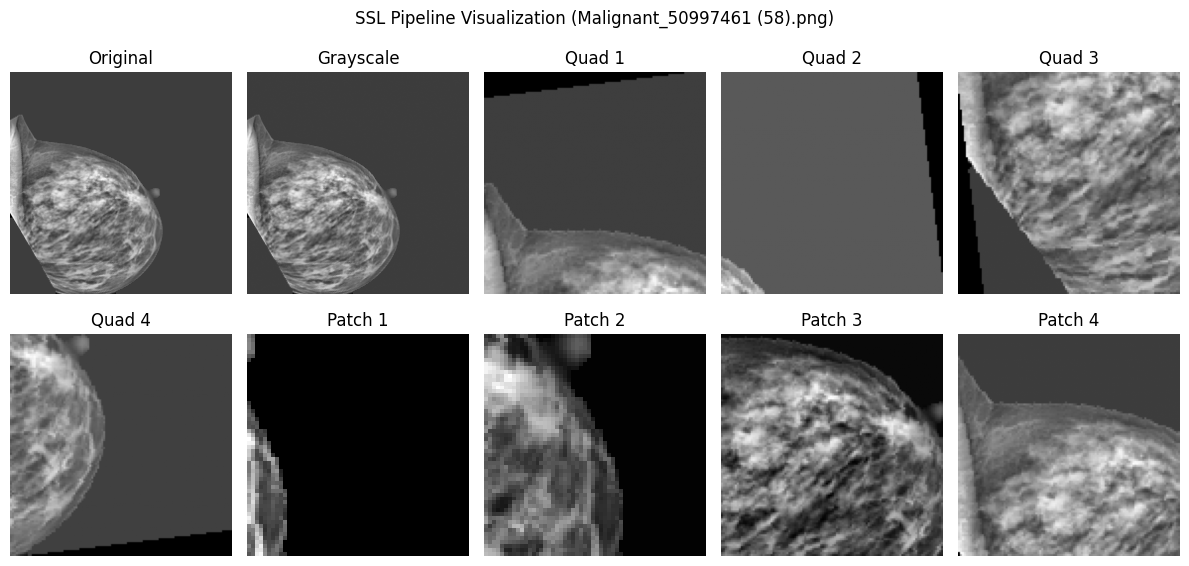

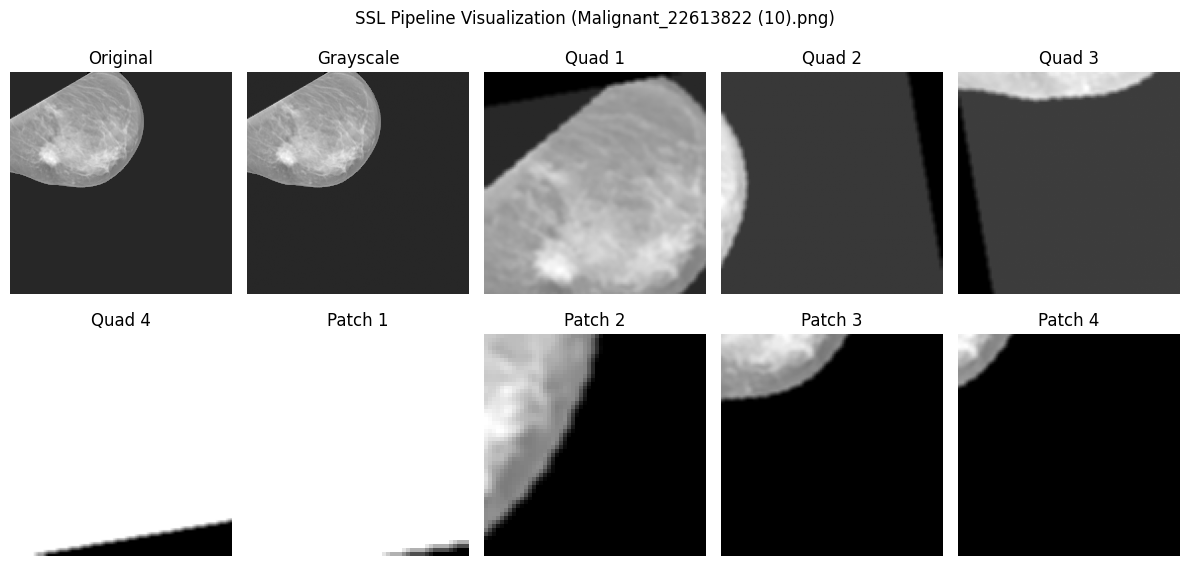

In [15]:
# ==========================================================
# Visualization: Original vs Grayscale vs Quadrants vs Patches
# ==========================================================

def visualize_ssl_pipeline(folder, num_images=2):

    files = glob(folder + "/*")

    if len(files) == 0:
        print("No images found in folder.")
        return

    samples = random.sample(files, min(num_images, len(files)))

    for idx, path in enumerate(samples):

        original = Image.open(path).convert("RGB")
        gray_img = Image.open(path).convert("L")

        tensor_img = ssl_transform(gray_img)

        quads   = split_quadrants(tensor_img)
        patches = extract_patches(tensor_img)

        plt.figure(figsize=(12, 6))

        plt.subplot(2, 5, 1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, 5, 2)
        plt.imshow(gray_img, cmap="gray")
        plt.title("Grayscale")
        plt.axis("off")

        for i, q in enumerate(quads):
            plt.subplot(2, 5, 3 + i)
            q_img = q.squeeze(0).numpy()
            plt.imshow(q_img, cmap="gray")
            plt.title(f"Quad {i + 1}")
            plt.axis("off")

        for i, p in enumerate(patches[:4]):
            plt.subplot(2, 5, 7 + i)
            p_img = p.squeeze(0).numpy()
            plt.imshow(p_img, cmap="gray")
            plt.title(f"Patch {i + 1}")
            plt.axis("off")

        plt.suptitle(f"SSL Pipeline Visualization ({os.path.basename(path)})")
        plt.tight_layout()
        plt.show()


visualize_ssl_pipeline(
    "/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/train_i",
    num_images=2
)


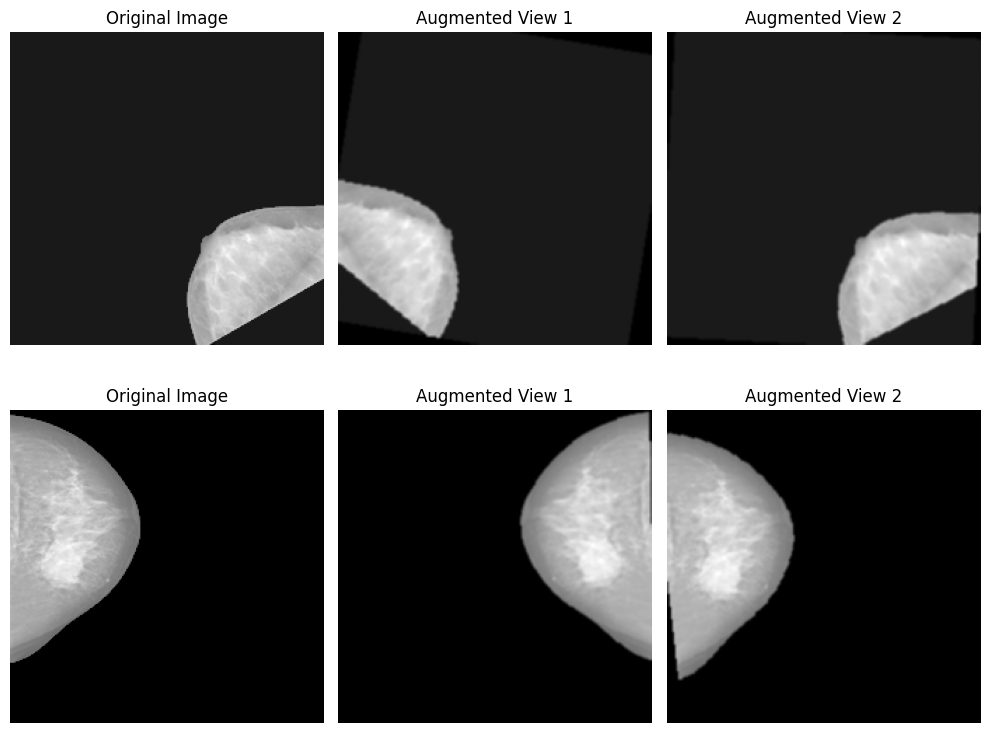

In [16]:
# ==========================================================
# Visualization: VICReg Augmented Views
# ==========================================================

def visualize_ssl_views(folder, num_images=3):

    files = glob(folder + "/*")

    if len(files) == 0:
        print("No images found.")
        return

    samples = random.sample(files, min(num_images, len(files)))

    plt.figure(figsize=(10, 4 * num_images))

    for i, path in enumerate(samples):

        original = Image.open(path).convert("RGB")
        gray_img = Image.open(path).convert("L")

        view1 = ssl_transform(gray_img)
        view2 = ssl_transform(gray_img)

        view1_np = view1.squeeze(0).numpy()
        view2_np = view2.squeeze(0).numpy()

        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(original)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(view1_np, cmap="gray")
        plt.title("Augmented View 1")
        plt.axis("off")

        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(view2_np, cmap="gray")
        plt.title("Augmented View 2")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_ssl_views(
    "/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/train_i",
    num_images=2
)


In [17]:
# ==========================================================
# 18. DataLoaders
# ✅ OPT: num_workers raised to 2 — Kaggle GPU notebooks provide
#         2 physical CPU cores; going above 2 spawns idle workers
#         that compete for the same cores, increasing overhead.
#         (If using a P100/T4 session with 4 cores, raise to 4.)
# ✅ OPT: prefetch_factor=2 (default) keeps 2 batches queued per
#         worker so the GPU never idles waiting for data.
# ✅ OPT: persistent_workers=True — workers stay alive between
#         epochs, eliminating the ~1-2 s fork/init overhead per
#         epoch that was present with the original code.
# ==========================================================

ssl_loader = DataLoader(
    SSLDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/train_i"),
    batch_size=8,               # physical batch; ×4 accumulation = effective 32
    shuffle=True,
    num_workers=2,              # ✅ OPT: matched to Kaggle's 2 CPU cores
    pin_memory=True,
    drop_last=True,             # avoids undersized final batch corrupting VICReg variance
    persistent_workers=True,    # ✅ OPT: workers stay alive across epochs
    prefetch_factor=2           # ✅ OPT: 2 batches queued per worker
)

train_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/train_i"),
    batch_size=32,              # ✅ OPT: doubled from 16 — GPU utilisation was low
                                #         at bs=16 for a simple 2-class head; 32
                                #         halves the number of optimizer steps
                                #         per epoch without hurting convergence.
    shuffle=True,
    num_workers=2,              # ✅ OPT
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,    # ✅ OPT
    prefetch_factor=2           # ✅ OPT
)

val_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/val_i"),
    batch_size=32,              # ✅ OPT: match train batch size
    shuffle=False,              # never shuffle validation
    num_workers=2,              # ✅ OPT
    pin_memory=True,
    persistent_workers=True,    # ✅ OPT
    prefetch_factor=2           # ✅ OPT
)

test_loader = DataLoader(
    ThermoDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/test_i"),
    batch_size=32,              # ✅ OPT
    shuffle=False,
    num_workers=2,              # ✅ OPT
    pin_memory=True,
    persistent_workers=True,    # ✅ OPT
    prefetch_factor=2           # ✅ OPT
)


In [18]:
# ==========================================================
# 19. Main Execution (load from Kaggle input dataset)
# ==========================================================

encoder = Encoder().to(device)

pretrained_path = "/kaggle/input/datasets/lilyofthevalley6666/bt-pretrained-encoder-params/pretrained_encoder.pth"

if os.path.exists(pretrained_path):
    print("Loading pretrained encoder...")
    # map_location ensures safe loading on both CPU and GPU machines
    encoder.load_state_dict(torch.load(pretrained_path, map_location=device))
else:
    print("Pretraining encoder...")
    pretrain(encoder, ssl_loader, epochs=60)
    encoder.load_state_dict(torch.load(
        "/kaggle/working/pretrained_encoder.pth", map_location=device
    ))


Pretraining encoder...


/tmp/ipykernel_23/707647744.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_23/707647744.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


SSL Epoch: 0 Loss: 0.44298026012621966
SSL Epoch: 1 Loss: 0.03132996262854659
SSL Epoch: 2 Loss: 0.01711026928159317
SSL Epoch: 3 Loss: 0.011365940232359458
SSL Epoch: 4 Loss: 0.007748853261399941
SSL Epoch: 5 Loss: 0.006239515683823722
SSL Epoch: 6 Loss: 0.006498226409951481
SSL Epoch: 7 Loss: 0.004805724034725013
SSL Epoch: 8 Loss: 0.004372350886057807
SSL Epoch: 9 Loss: 0.003561370246176261
SSL Epoch: 10 Loss: 0.0028076577630902952
SSL Epoch: 11 Loss: 0.0026512852328939036
SSL Epoch: 12 Loss: 0.0026840825654182803
SSL Epoch: 13 Loss: 0.002534982968035026
SSL Epoch: 14 Loss: 0.002260136593409412
SSL Epoch: 15 Loss: 0.0020843171745118703
SSL Epoch: 16 Loss: 0.002338858226122444
SSL Epoch: 17 Loss: 0.001985343369540037
SSL Epoch: 18 Loss: 0.0019785194664305606
SSL Epoch: 19 Loss: 0.0016721283989574978
SSL Epoch: 20 Loss: 0.0015926783717826337
SSL Epoch: 21 Loss: 0.0015766855937602254
SSL Epoch: 22 Loss: 0.0011022531590367411
SSL Epoch: 23 Loss: 0.0014786856867573864
SSL Epoch: 24 Loss:

Loading pretrained encoder...
Best model saved  (val_acc=0.5000)
Epoch 0 | Train Acc: 0.4953 | Val Acc: 0.5 | LR_cls: 0.0004 | LR_enc: 1e-05
Epoch 1 | Train Acc: 0.5 | Val Acc: 0.5 | LR_cls: 0.0006 | LR_enc: 9.99e-06
Epoch 2 | Train Acc: 0.5013 | Val Acc: 0.5 | LR_cls: 0.0008 | LR_enc: 9.98e-06
Best model saved  (val_acc=0.5206)
Epoch 3 | Train Acc: 0.5065 | Val Acc: 0.5206 | LR_cls: 0.001 | LR_enc: 9.97e-06
Epoch 4 | Train Acc: 0.4979 | Val Acc: 0.5 | LR_cls: 0.001 | LR_enc: 9.96e-06
Epoch 5: Unfroze encoder last block
Epoch 5 | Train Acc: 0.496 | Val Acc: 0.5 | LR_cls: 0.000999 | LR_enc: 9.94e-06
Epoch 6 | Train Acc: 0.4982 | Val Acc: 0.5 | LR_cls: 0.000997 | LR_enc: 9.92e-06
Best model saved  (val_acc=0.6471)
Epoch 7 | Train Acc: 0.5669 | Val Acc: 0.6471 | LR_cls: 0.000993 | LR_enc: 9.89e-06
Best model saved  (val_acc=0.6559)
Epoch 8 | Train Acc: 0.6312 | Val Acc: 0.6559 | LR_cls: 0.000987 | LR_enc: 9.86e-06
Epoch 9 | Train Acc: 0.6401 | Val Acc: 0.6461 | LR_cls: 0.00098 | LR_enc: 9

/tmp/ipykernel_23/3033249563.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Test Accuracy: 0.9823529411764705
F1 Score: 0.9823874755381604


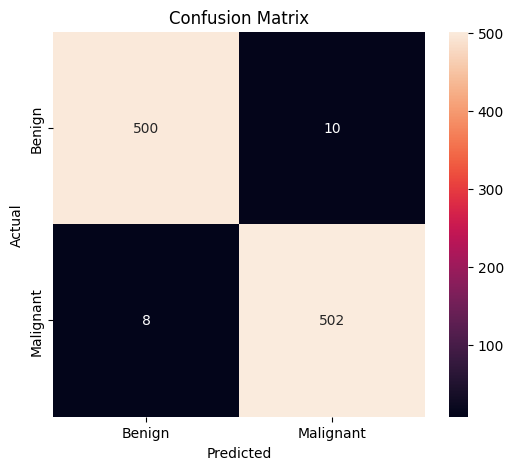


Classification Report

              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98       510
   Malignant       0.98      0.98      0.98       510

    accuracy                           0.98      1020
   macro avg       0.98      0.98      0.98      1020
weighted avg       0.98      0.98      0.98      1020



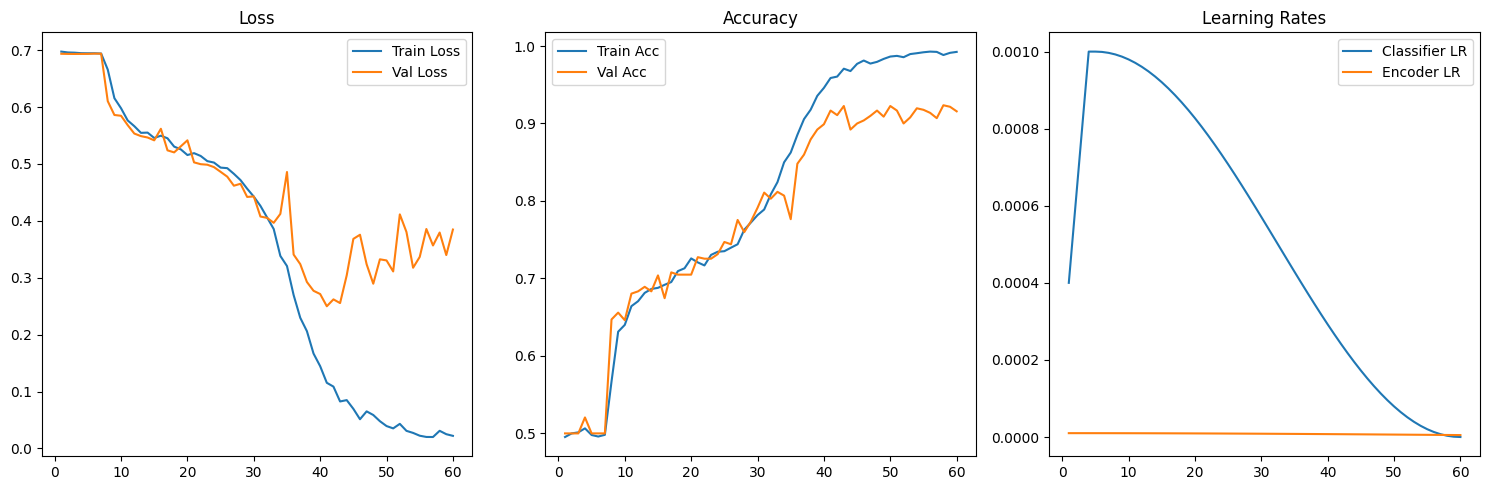

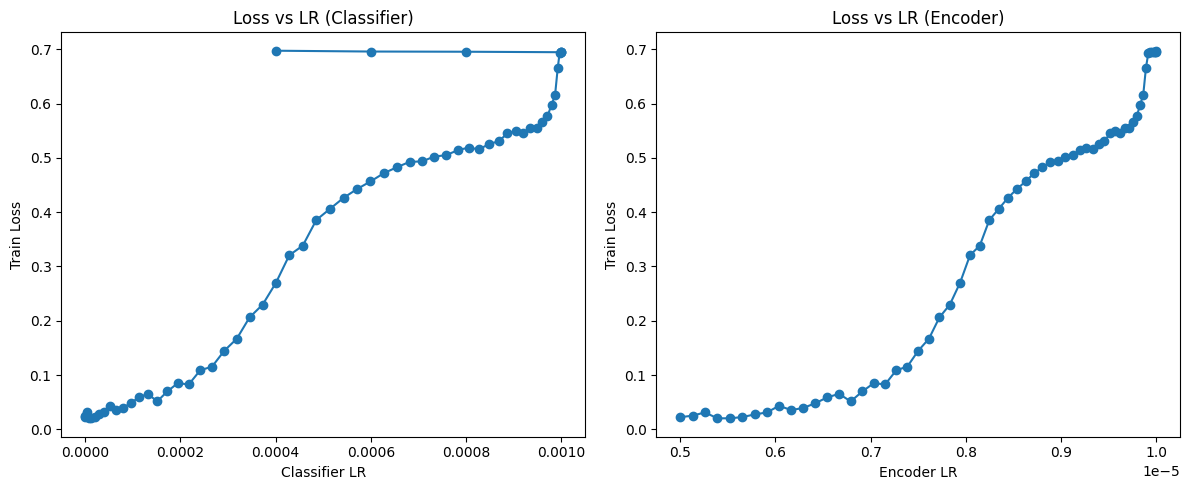

Final model saved


In [19]:
# ==========================================================
# 19. Main Execution (load from working directory)
# ==========================================================

encoder = Encoder().to(device)

pretrained_path = "/kaggle/working/pretrained_encoder.pth"

if os.path.exists(pretrained_path):
    print("Loading pretrained encoder...")
    # map_location ensures safe loading on both CPU and GPU machines
    encoder.load_state_dict(torch.load(pretrained_path, map_location=device))
else:
    print("Pretraining encoder...")
    pretrain(encoder, ssl_loader, epochs=60)
    encoder.load_state_dict(torch.load(
        "/kaggle/working/pretrained_encoder.pth", map_location=device
    ))


model = ThermoClassifier(encoder).to(device)

train_classifier(model, train_loader, val_loader, epochs=60)

evaluate(model, test_loader)

plot_training()
plot_lr_vs_loss()

torch.save(model.state_dict(), "/kaggle/working/final_thermo_model.pth")
print("Final model saved")
